# MUSIN-G EEG Analysis: ICA + Band Power

This notebook loads the MUSIN-G dataset, applies ICA decomposition to EEG data,
and computes band power for each ICA component across sliding windows.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
from numpy.typing import NDArray

from eeg_music.data import EEGMusicDataset
from eeg_music.ica_analysis import (
    apply_ica,
    clean_ica_artifacts,
    ica_band_power_trial,
    windowed_band_power,
)

/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


In [2]:
ds = EEGMusicDataset.load_ondisk(Path("./datasets/musin_g_export2"))
print(f"Dataset size: {len(ds)} trials")

Dataset size: 240 trials


## Load first trial and apply ICA

In [3]:
raw = ds[0].eeg_data.get_eeg().raw_eeg.copy()
raw.filter(l_freq=1.0, h_freq=50.0, verbose=False)
# GSN-HydroCel-129 montage labels the 129th electrode as "Cz", not "E129"
if "E129" in raw.ch_names:
    raw.rename_channels({"E129": "Cz"})
raw.set_montage(mne.channels.make_standard_montage("GSN-HydroCel-129"), on_missing="warn")
print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11, E12, E13, E14, ...
 chs: 129 EEG
 custom_ref_applied: False
 dig: 132 items (3 Cardinal, 129 EEG)
 highpass: 1.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1985-01-01 00:00:00 UTC
 nchan: 129
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [4]:
ica, sources = apply_ica(raw, n_components=20)
print(f"ICA components: {ica.n_components_}")

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Selecting by number: 20 components
Selecting by number: 20 components
Fitting ICA took 1.8s.
Fitting ICA took 1.8s.
ICA components: 20
ICA components: 20


In [5]:
cleaned = clean_ica_artifacts(ica, raw)

/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Transforming to ICA space (20 components)
    Zeroing out 8 ICA components
    Projecting back using 129 PCA components
    Zeroing out 8 ICA components
    Projecting back using 129 PCA components


Using matplotlib as 2D backend.


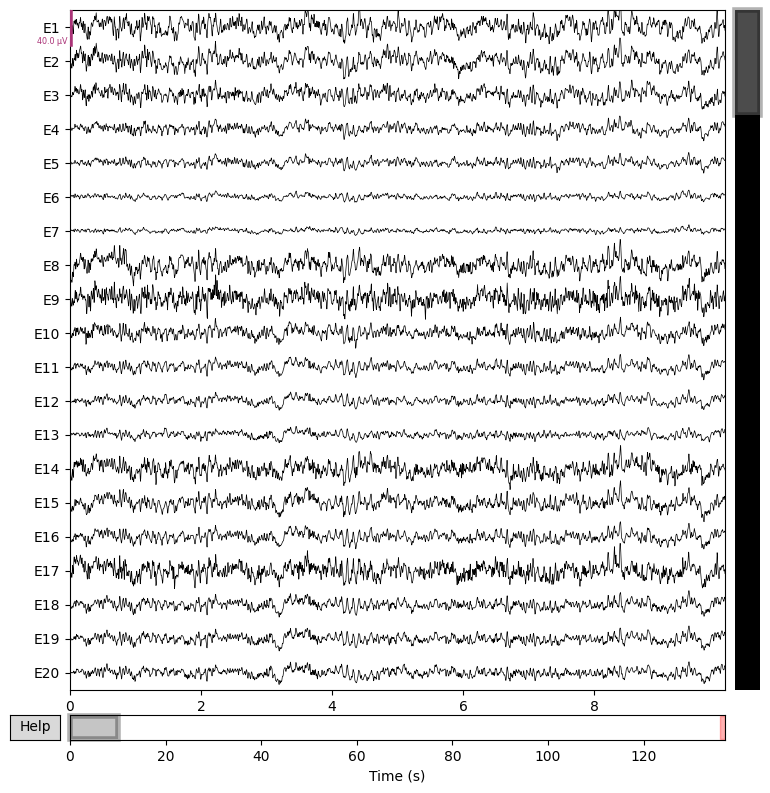

In [6]:
cleaned.plot(n_channels=min(20, len(cleaned.ch_names)), duration=10, title="Cleaned EEG (artifacts removed)")
plt.show()

## Band power analysis on ICA components

In [7]:
BANDS = [(0.5, 4), (4, 8), (8, 13), (13, 30), (30, 45)]

# Get ICA sources from cleaned data for band power analysis
cleaned_sources = ica.get_sources(cleaned)
bp, band_names = windowed_band_power(cleaned_sources, bands=BANDS, window_sec=2.0, hop_sec=1.0)
print(f"Band power shape (num_bands, num_components, num_windows): {bp.shape}")

Band power shape (num_bands, num_components, num_windows): (5, 20, 136)


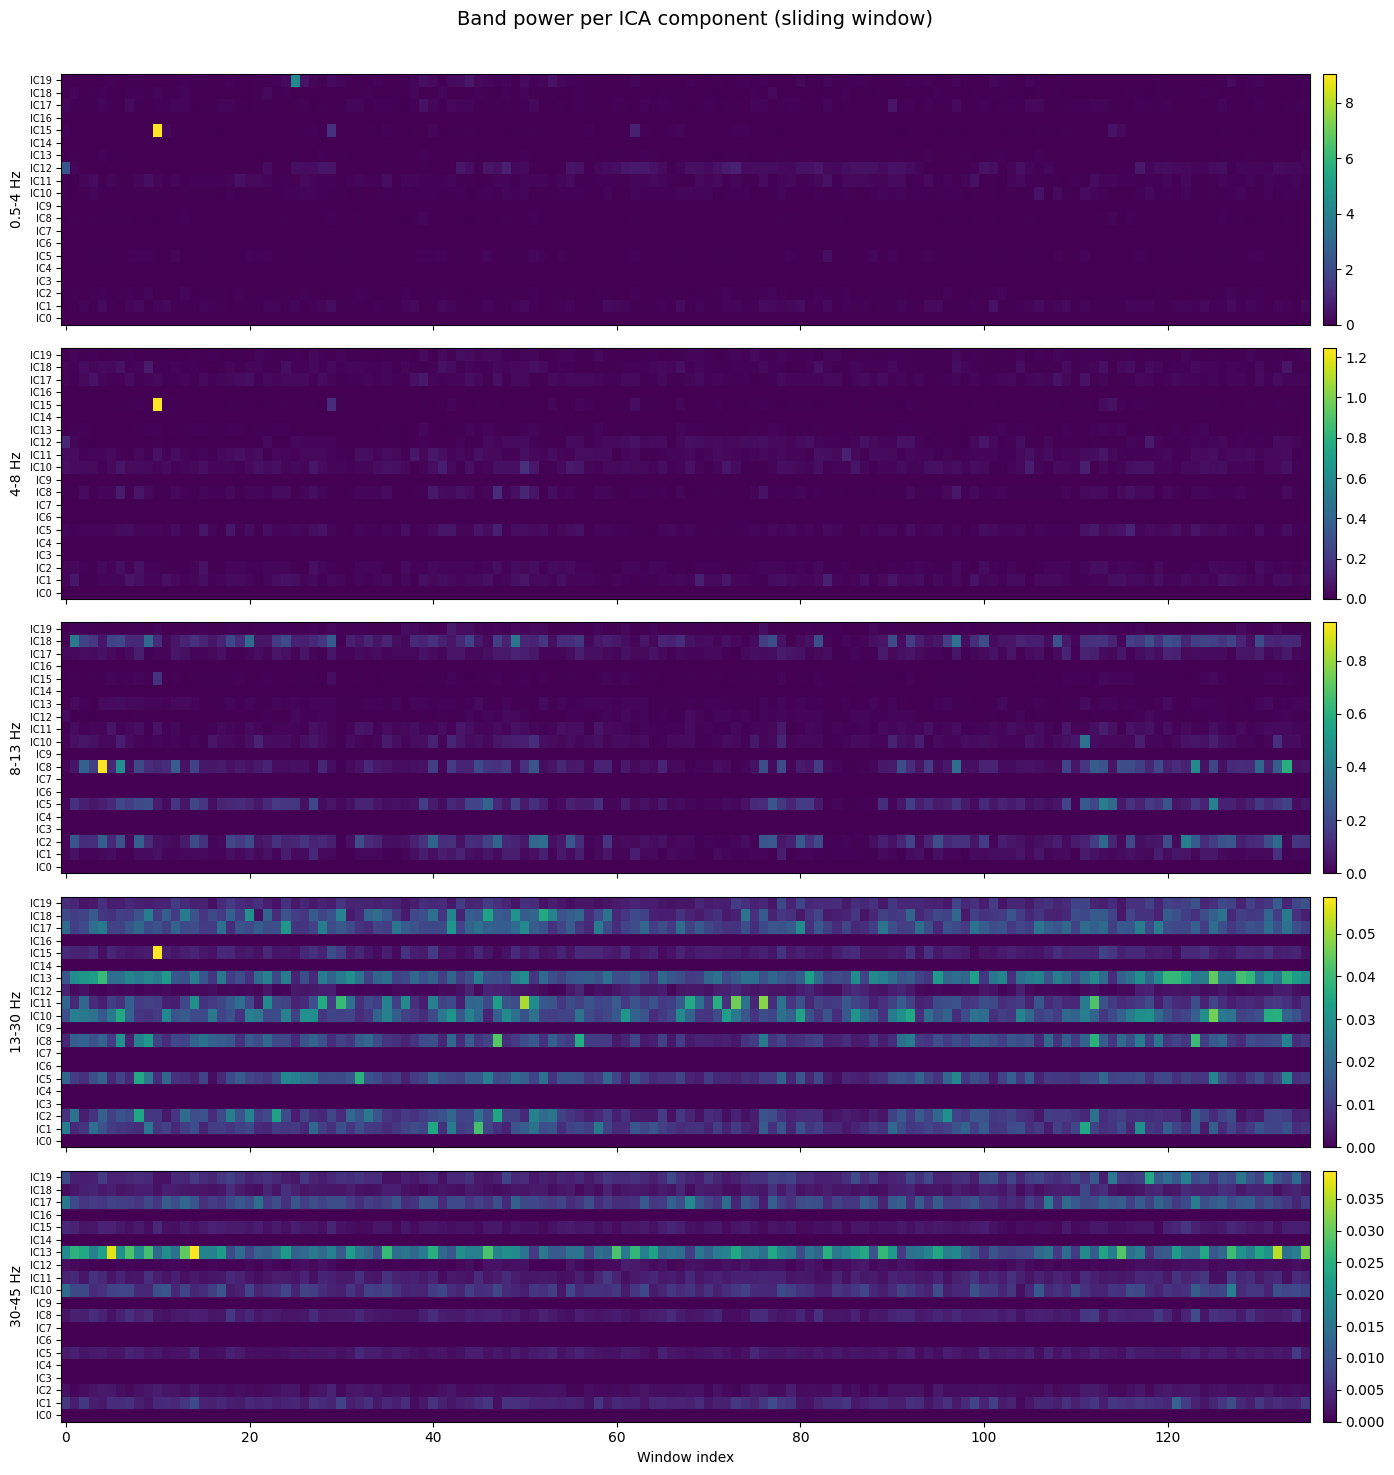

In [8]:
fig, axs = plt.subplots(len(BANDS), 1, figsize=(14, 3 * len(BANDS)), sharex=True)
for i, (name, band_data) in enumerate(zip(band_names, bp)):
    im = axs[i].imshow(band_data, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
    axs[i].set_ylabel(name)
    axs[i].set_yticks(range(band_data.shape[0]))
    axs[i].set_yticklabels([f"IC{j}" for j in range(band_data.shape[0])], fontsize=7)
    fig.colorbar(im, ax=axs[i], orientation="vertical", pad=0.01, fraction=0.03)
axs[-1].set_xlabel("Window index")
fig.suptitle("Band power per ICA component (sliding window)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Combined pipeline: ica_band_power_trial

Single function that takes a trial and returns a new trial with ArrayEeg containing
band power features from ICA-cleaned sources.

In [9]:
result = ica_band_power_trial(ds[3])
arr = result.eeg_data.get_array()
print(f"Output shape: {arr.data.shape}  (channels x windows)")
print(f"Channel names ({len(arr.ch_names)}): {arr.ch_names[:10]} ...")
print(f"sfreq: {arr.sfreq} Hz")
print(result.pretty())

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 129 of 30500 (0.42%) samples, retaining 30371 (99.58%) samples.
Omitting 129 of 30500 (0.42%) samples, retaining 30371 (99.58%) samples.
Selecting by number: 20 components
Selecting by number: 20 components
Fitting ICA took 0.9s.
Fitting ICA took 0.9s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 9 ICA components
    Projecting back using 129 PCA components
    Transforming to ICA space (20 components)
    Zeroing out 9 ICA components
    Projecting back using 129 PCA components
Output shape: (100, 121)  (channels x windows)
Channel names (100): ['delta_IC0', 'delta_IC1', 'delta_IC2', 'delta_IC3', 'delta_IC4', 'delta_IC5', 'delta_IC6', 'delta_IC7', 'delta_IC8', 'delta_IC9'] ...
sfreq: 1.0 Hz
TrialData(
  dataset=musin-g, subject=001, session=04, run=4, trial_id=song_04,
  music_filename=song_04.wav,
  eeg=ArrayEeg(sfreq=1, chans=100, secs=121.000, samples=121),
  music=MusingMusicIdData
)
Output shape: (100, 121)  (channels x windows)
Channel names (100): ['delta_IC0', 'delta_IC1', 'delta_IC2', 'delta_IC3', 'delta_IC4', 'delta_IC5', 'delta_IC6', 'delta_IC7', 'delta_IC8', 'delta_IC9'] ...
sfreq: 1.0 Hz
TrialData(
  dataset=musin-g, subject=001, session=04, run=4, trial_id=song_04,
  music_

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 129 of 30500 (0.42%) samples, retaining 30371 (99.58%) samples.
Selecting by number: 8 components
Fitting ICA took 0.3s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 3 ICA components
    Projecting back using 129 PCA components


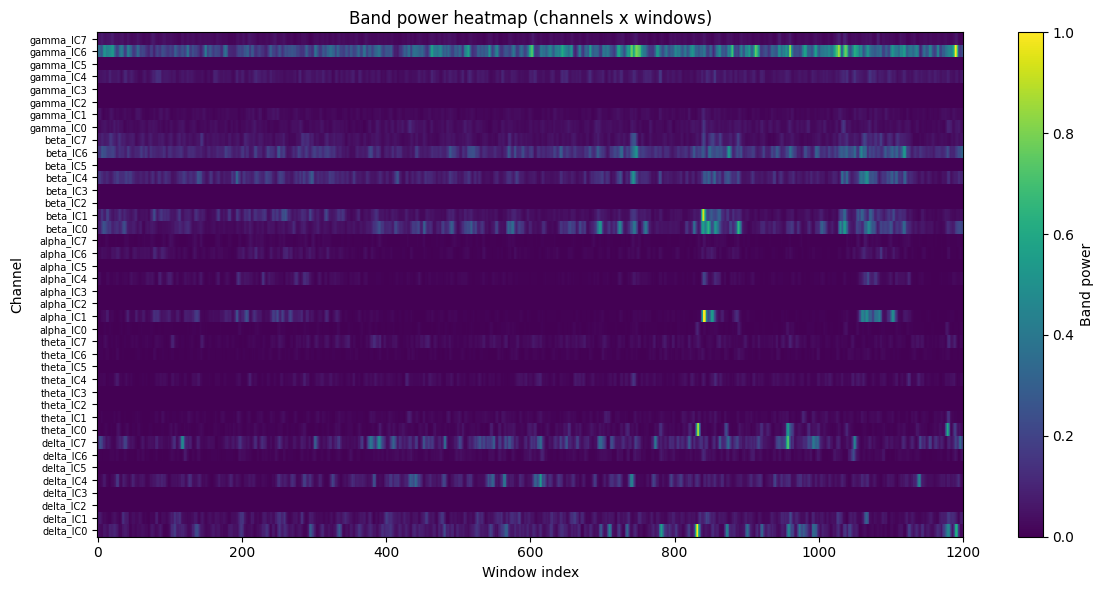

In [3]:
from eeg_music.ica_analysis import ica_band_power_trial
f = lambda t: ica_band_power_trial(
    trial=t,
    n_components=8,
    bands = [(0.5, 4), (4, 8), (8, 13), (13, 30), (30, 45)],
    window_sec= 2.0,
    hop_sec = 0.1,
    l_freq = 1.0,
    h_freq = 50.0,
    keep_labels = {"brain", "other"},
)
fds0 = f(ds[3])

data = fds0.eeg_data.get_array().data
ch_names = fds0.eeg_data.get_array().ch_names
plt.figure(figsize=(12, 6))
im = plt.imshow(data, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
plt.colorbar(im, label="Band power")
plt.xlabel("Window index")
plt.ylabel("Channel")
if len(ch_names) <= 40:
  plt.yticks(range(len(ch_names)), ch_names, fontsize=7)
else:
  step = max(1, len(ch_names) // 40)
  plt.yticks(range(0, len(ch_names), step), [ch_names[i] for i in range(0, len(ch_names), step)], fontsize=7)
plt.title("Band power heatmap (channels x windows)")
plt.tight_layout()
plt.show()

In [8]:
combined_dataset = ds
filtered_ds = EEGMusicDataset()
filtered_ds.df = combined_dataset.df.loc[(combined_dataset.df.subject == "001")].reset_index(drop=True)
filtered_ds.music_collection = combined_dataset.music_collection
len(filtered_ds)

12

In [10]:
from eeg_music.data import MappedDataset
mds = MappedDataset(
  ds,
  f
)
mds[0]

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Selecting by number: 8 components
Fitting ICA took 0.3s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components


TrialData(dataset='musin-g', subject='001', session='01', run='1', trial_id='song_01', music_filename=MusicFilename(filename='song_01.wav'), eeg_data=ArrayEeg(data=array([[8.13398976e-03, 7.16499565e-03, 5.68009447e-03, ...,
        8.42914544e-03, 7.85386376e-03, 1.08851818e-02],
       [1.18935322e-02, 1.32979285e-02, 1.36045320e-02, ...,
        3.57956672e-03, 5.23815816e-03, 9.25276522e-03],
       [2.38302965e-02, 2.42976062e-02, 2.22382788e-02, ...,
        1.09793553e-02, 9.60667245e-03, 9.20898188e-03],
       ...,
       [1.76199750e-31, 1.71790294e-31, 1.87765251e-31, ...,
        1.29309069e-31, 1.33921215e-31, 1.66830073e-31],
       [1.26420186e-30, 1.30120237e-30, 1.56012278e-30, ...,
        6.63009753e-31, 7.90147460e-31, 8.60338015e-31],
       [1.04256712e-01, 2.51221269e-01, 4.68409866e-01, ...,
        9.99402925e-02, 6.83017150e-02, 4.51156870e-02]], dtype=float32), ch_names=['delta_IC0', 'delta_IC1', 'delta_IC2', 'delta_IC3', 'delta_IC4', 'delta_IC5', 'delta_IC6'

In [22]:
m_filtered_ds = MappedDataset(filtered_ds, f)
m_filtered_ds[0]

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Selecting by number: 8 components
Fitting ICA took 0.3s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components


TrialData(dataset='musin-g', subject='001', session='01', run='1', trial_id='song_01', music_filename=MusicFilename(filename='song_01.wav'), eeg_data=ArrayEeg(data=array([[8.13398976e-03, 7.16499565e-03, 5.68009447e-03, ...,
        8.42914544e-03, 7.85386376e-03, 1.08851818e-02],
       [1.18935322e-02, 1.32979285e-02, 1.36045320e-02, ...,
        3.57956672e-03, 5.23815816e-03, 9.25276522e-03],
       [2.38302965e-02, 2.42976062e-02, 2.22382788e-02, ...,
        1.09793553e-02, 9.60667245e-03, 9.20898188e-03],
       ...,
       [1.76199750e-31, 1.71790294e-31, 1.87765251e-31, ...,
        1.29309069e-31, 1.33921215e-31, 1.66830073e-31],
       [1.26420186e-30, 1.30120237e-30, 1.56012278e-30, ...,
        6.63009753e-31, 7.90147460e-31, 8.60338015e-31],
       [1.04256712e-01, 2.51221269e-01, 4.68409866e-01, ...,
        9.99402925e-02, 6.83017150e-02, 4.51156870e-02]], dtype=float32), ch_names=['delta_IC0', 'delta_IC1', 'delta_IC2', 'delta_IC3', 'delta_IC4', 'delta_IC5', 'delta_IC6'

In [23]:
from fractions import Fraction
from eeg_music.data import temporal_train_test_split

# train_ds, test_ds = temporal_train_test_split(filtered_ds, Fraction(20, 1))

train_onesubj_ds, test_onesubj_ds = temporal_train_test_split(m_filtered_ds, Fraction(20, 1))

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Selecting by number: 8 components
Fitting ICA took 0.3s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 21 of 31250 (0.07%) samples, retaining 31229 (99.93%) samples.
Selecting by number: 8 components
Fitting ICA took 0.4s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 5 ICA components
    Projecting back using 129 PCA components
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 54 of 35750 (0.15%) samples, retaining 35696 (99.85%) samples.
Selecting by number: 8 components
Fitting ICA took 0.3s.


...

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 3 ICA components
    Projecting back using 129 PCA components
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 212 of 31000 (0.68%) samples, retaining 30788 (99.32%) samples.
Selecting by number: 8 components
Fitting ICA took 0.2s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 45 of 32000 (0.14%) samples, retaining 31955 (99.86%) samples.
Selecting by number: 8 components
Fitting ICA took 0.3s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:41: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components


In [13]:
train_onesubj_ds.save(Path("./datasets/musing_preprocessed/train_onesubj_musing_ica_40ch"))
test_onesubj_ds.save(Path("./datasets/musing_preprocessed/test_onesubj_musing_ica_40ch"))

In [27]:
some_train_ds = EEGMusicDataset.load_ondisk(Path("./datasets/musing_preprocessed/train_onesubj_musing_ica_40ch"))
some_test_ds = EEGMusicDataset.load_ondisk(Path("./datasets/musing_preprocessed/test_onesubj_musing_ica_40ch"))
print(some_train_ds[0].eeg_data.get_array().data.shape)
print(some_test_ds[0].eeg_data.get_array().data.shape)

(40, 200)
(40, 1151)


In [6]:
def plot_eeg_lengths_histogram(dataset, bins=30, figsize=(8, 4), show=True):
  """Plot histogram of EEG durations (seconds) for a given EEGMusicDataset-like iterable."""
  lengths = []
  for t in dataset:
    # try MNE Raw path
    try:
      eeg = t.eeg_data.get_eeg()
      raw = getattr(eeg, "raw_eeg", eeg)
      if hasattr(raw, "times"):
        lengths.append(float(raw.times[-1] - raw.times[0]) if raw.times.size else 0.0)
        continue
      if hasattr(raw, "n_times") and hasattr(raw, "info") and raw.info.get("sfreq"):
        lengths.append(float(raw.n_times) / float(raw.info["sfreq"]))
        continue
    except Exception:
      pass
    # fallback to array-like eeg_data
    arr = getattr(t.eeg_data, "data", None) or (getattr(t.eeg_data, "get_array", lambda: None)() and t.eeg_data.get_array().data)
    sf = getattr(t.eeg_data, "sfreq", None) or (getattr(t.eeg_data, "get_array", lambda: None)() and t.eeg_data.get_array().sfreq)
    if arr is not None:
      lengths.append(arr.shape[1] / sf if sf else float(arr.shape[1]))
    else:
      # unknown format, skip
      continue

  lengths = np.array(lengths, dtype=float)
  plt.figure(figsize=figsize)
  plt.hist(lengths, bins=bins, color="C0", edgecolor="k")
  plt.xlabel("Duration (s)")
  plt.ylabel("Count")
  plt.title(f"EEG lengths (n={len(lengths)})")
  plt.grid(True, linestyle=":", alpha=0.4)
  if show:
    plt.show()
  return lengths

In [10]:
train_mds[0].eeg_data.get_array().data.shape

(40, 200)

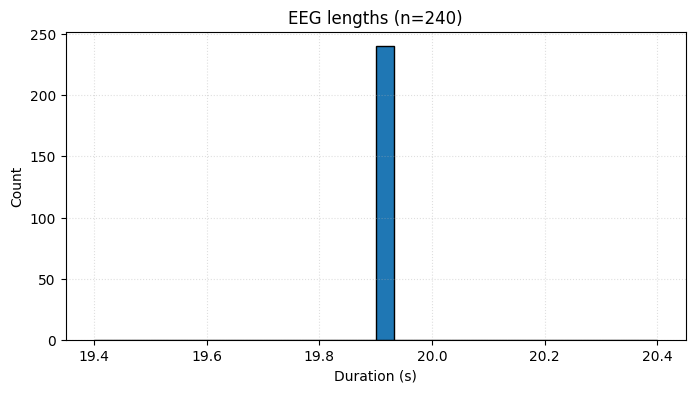

array([19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9,
       19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19.9, 19

In [7]:
plot_eeg_lengths_histogram(train_mds)

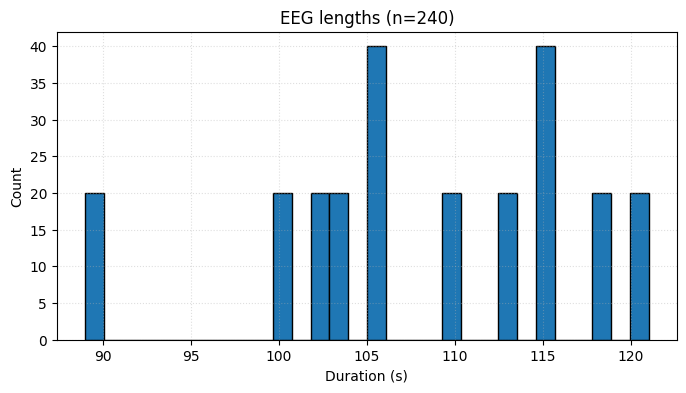

array([115., 103., 121., 100., 113.,  89., 105., 110., 115., 118., 102.,
       106., 115., 103., 121., 100., 113.,  89., 105., 110., 115., 118.,
       102., 106., 115., 103., 121., 100., 113.,  89., 105., 110., 115.,
       118., 102., 106., 115., 103., 121., 100., 113.,  89., 105., 110.,
       115., 118., 102., 106., 115., 103., 121., 100., 113.,  89., 105.,
       110., 115., 118., 102., 106., 115., 103., 121., 100., 113.,  89.,
       105., 110., 115., 118., 102., 106., 115., 103., 121., 100., 113.,
        89., 105., 110., 115., 118., 102., 106., 115., 103., 121., 100.,
       113.,  89., 105., 110., 115., 118., 102., 106., 115., 103., 121.,
       100., 113.,  89., 105., 110., 115., 118., 102., 106., 115., 103.,
       121., 100., 113.,  89., 105., 110., 115., 118., 102., 106., 115.,
       103., 121., 100., 113.,  89., 105., 110., 115., 118., 102., 106.,
       115., 103., 121., 100., 113.,  89., 105., 110., 115., 118., 102.,
       106., 115., 103., 121., 100., 113.,  89., 10

In [8]:
plot_eeg_lengths_histogram(test_mds)

In [18]:
mds.save(Path("./datasets/musing_preprocessed/musing_ica_8ch"))

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Selecting by number: 8 components
Fitting ICA took 0.4s.
Selecting by number: 8 components
Fitting ICA took 0.4s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 21 of 31250 (0.07%) samples, retaining 31229 (99.93%) samples.
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 21 of 31250 (0.07%) samples, retaining 31229 (99.93%) samples.
Selecting by number: 8 components
Selecting by number: 8 components
Fitting ICA took 0.7s.
Fitting ICA took 0.7s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Transforming to ICA space (8 components)
    Zeroing out 5 ICA components
    Projecting back using 129 PCA components
    Zeroing out 5 ICA components
    Projecting back using 129 PCA components
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 54 of 35750 (0.15%) samples, retaining 35696 (99.85%) samples.
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 54 of 35750 (0.15%) samples, retaining 35696 (99.85%) samples.
Selecting by number: 8 components
Selecting by number: 8 components
Fitting ICA took 0.6s.
Fitting ICA took 0.6s.


...

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 3 ICA components
    Projecting back using 129 PCA components
    Transforming to ICA space (8 components)
    Zeroing out 3 ICA components
    Projecting back using 129 PCA components
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 850 of 124000 (0.69%) samples, retaining 123150 (99.31%) samples.
Selecting by number: 8 components
Fitting ICA took 1.5s.
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 850 of 124000 (0.69%) samples, retaining 123150 (99.31%) samples.
Selecting by number: 8 components
Fitting ICA took 1.5s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 2 ICA components
    Projecting back using 129 PCA components
    Transforming to ICA space (8 components)
    Zeroing out 2 ICA components
    Projecting back using 129 PCA components
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 184 of 128000 (0.14%) samples, retaining 127816 (99.86%) samples.
Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 184 of 128000 (0.14%) samples, retaining 127816 (99.86%) samples.
Selecting by number: 8 components
Fitting ICA took 1.7s.
Selecting by number: 8 components
Fitting ICA took 1.7s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 3 ICA components
    Projecting back using 129 PCA components
    Transforming to ICA space (8 components)
    Zeroing out 3 ICA components
    Projecting back using 129 PCA components


In [21]:
mds[0].eeg_data.data.shape

Fitting ICA to data using 129 channels (please be patient, this may take a while)
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Omitting 241 of 34250 (0.70%) samples, retaining 34009 (99.30%) samples.
Selecting by number: 8 components
Selecting by number: 8 components
Fitting ICA took 0.3s.
Fitting ICA took 0.3s.


/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/ica_analysis.py:39: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Transforming to ICA space (8 components)
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components
    Zeroing out 4 ICA components
    Projecting back using 129 PCA components


(40, 1351)